# Phase 3: Operations Research - Markdown Optimization

In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import LabelEncoder

# --- 1. SETTINGS & UTILS ---
models_dir = 'trained_models'
all_stores = ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
discount_levels = [0.0, 0.10, 0.20]
dept_cost_map = {'FOODS': 0.80, 'HOUSEHOLD': 0.65, 'HOBBIES': 0.50}

features = [
    'item_id_encoded', 'dept_id_encoded', 'cat_id_encoded',
    'wday', 'month', 'sell_price', 'lag_7', 'rolling_mean_7',
    'lag_14', 'lag_28', 'price_diff', 'event_name_1_encoded', 'year',
    'is_snap_day', 'avg_sales_on_weekday', 'cat_volume_last_7d'
]

# --- 2. DATA LOADING ---
print("Loading Base Data...")
cal = pd.read_csv('/content/calendar.csv')
sell_price = pd.read_csv('/content/sell_prices.csv')
sal_eval = pd.read_csv('/content/sales_train_evaluation.csv')

cal['date'] = pd.to_datetime(cal['date'])

# Label Encoding (Global)
le_item = LabelEncoder().fit(sal_eval['item_id'])
le_dept = LabelEncoder().fit(sal_eval['dept_id'])
le_cat = LabelEncoder().fit(sal_eval['cat_id'])
le_event = LabelEncoder()
cal['event_name_1'] = cal['event_name_1'].fillna('NoEvent')
cal['event_name_1_encoded'] = le_event.fit_transform(cal['event_name_1'])

# Melt
sal_eval = sal_eval[['id', 'item_id', 'dept_id', 'cat_id', 'store_id'] + [f'd_{i}' for i in range(1413, 1942)]]
sal_eval_melted = pd.melt(sal_eval, id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id'], var_name='d', value_name='sales')
sal_eval_melted['date'] = pd.to_datetime(sal_eval_melted['d'].str.replace('d_', '').astype(int), origin='2011-01-29', unit='D')

# --- 3. RECURSIVE FUNCTION (WITH SAFETY CHECK) ---
def run_recursive_simulation(model, df_input, horizon, cat_avg_lk, dept_avg_lk, features):
    df = df_input.copy()
    for col in ['cat_day_avg', 'dept_day_avg', 'sales']:
        df[col] = 0.0

    start_date = df['date'].min()
    for d in range(horizon):
        curr_date = start_date + pd.Timedelta(days=d)
        mask = df['date'] == curr_date

        if mask.any():
            # 1. Mapping
            df.loc[mask, 'cat_day_avg'] = df.loc[mask, 'cat_id'].map(lambda x: cat_avg_lk.get((x, curr_date), 0.0))
            df.loc[mask, 'dept_day_avg'] = df.loc[mask, 'dept_id'].map(lambda x: dept_avg_lk.get((x, curr_date), 0.0))

            # 2. Predict (The safety check for 2D non-empty data)
            curr_step = df.loc[mask, features].fillna(0)
            if not curr_step.empty:
                df.loc[mask, 'sales'] = model.predict(curr_step).clip(0)

            # 3. Update Lags for future steps
            for lag in [7, 14, 28]:
                target_date = curr_date + pd.Timedelta(days=lag)
                t_mask = df['date'] == target_date
                if t_mask.any():
                    sales_map = df.loc[mask].set_index('item_id')['sales'].to_dict()
                    df.loc[t_mask, f'lag_{lag}'] = df.loc[t_mask, 'item_id'].map(sales_map).fillna(df.loc[t_mask, f'lag_{lag}'])

    return df

# --- 4. MAIN SIMULATION LOOP ---
all_simulated_scenarios = []

for store in all_stores:
    print(f"\n>>> Processing Store: {store}")
    model_path = os.path.join(models_dir, f'lgbm_model_{store}.joblib')
    if not os.path.exists(model_path):
        print(f"Skipping {store}: Model not found.")
        continue
    model = joblib.load(model_path)

    # Filter store data
    st_full = sal_eval_melted[sal_eval_melted['store_id'] == store].copy()

    # Enrich with Calendar
    state = store.split('_')[0]
    st_full = st_full.merge(cal[['date', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1_encoded', f'snap_{state}']], on='date', how='left')
    st_full.rename(columns={f'snap_{state}': 'is_snap_day'}, inplace=True)

    # Split History / Test
    st_history = st_full[st_full['date'] < '2016-05-23'].copy()
    st_test = st_full[st_full['date'] >= '2016-05-23'].copy()

    # Merge Prices & Drop items with NO price data (prevents empty input errors)
    st_test = st_test.merge(sell_price[sell_price['store_id']==store][['item_id', 'wm_yr_wk', 'sell_price']], on=['item_id', 'wm_yr_wk'], how='left')
    st_test = st_test.dropna(subset=['sell_price'])

    if st_test.empty:
        print(f"Warning: No valid price data for {store} in test period. Skipping.")
        continue

    # Feature Engineering
    st_test['item_id_encoded'] = le_item.transform(st_test['item_id'])
    st_test['dept_id_encoded'] = le_dept.transform(st_test['dept_id'])
    st_test['cat_id_encoded'] = le_cat.transform(st_test['cat_id'])

    hist_means = st_history.groupby('item_id')['sales'].mean().to_dict()
    st_test['lag_7'] = st_test['item_id'].map(hist_means).fillna(0)
    st_test['lag_14'] = st_test['lag_7']
    st_test['lag_28'] = st_test['lag_7']
    st_test['rolling_mean_7'] = st_test['lag_7']
    st_test['cat_volume_last_7d'] = 0.0

    weekday_map = st_history.groupby(['item_id', 'wday'])['sales'].mean().to_dict()
    st_test['avg_sales_on_weekday'] = [weekday_map.get((i, w), 0.0) for i, w in zip(st_test['item_id'], st_test['wday'])]

    cat_avg = st_history.groupby(['cat_id', 'date'])['sales'].mean().to_dict()
    dept_avg = st_history.groupby(['dept_id', 'date'])['sales'].mean().to_dict()
    base_prices = st_test.groupby('item_id')['sell_price'].mean().to_dict()

    for disc in discount_levels:
        print(f"  Simulating {int(disc*100)}% markdown...")
        sim_df = st_test.copy()
        sim_df['sell_price'] = sim_df['sell_price'] * (1 - disc)
        sim_df['price_diff'] = sim_df['sell_price'] - sim_df['item_id'].map(base_prices)

        res = run_recursive_simulation(model, sim_df, 28, cat_avg, dept_avg, features)

        # Economics
        res['cost_mult'] = res['dept_id'].str.split('_').str[0].map(dept_cost_map).fillna(0.7)
        res['unit_cost'] = res['item_id'].map(base_prices) * res['cost_mult']
        res['profit'] = (res['sell_price'] - res['unit_cost']) * res['sales']
        res['m_cost'] = (res['item_id'].map(base_prices) - res['sell_price']) * res['sales']

        agg = res.groupby(['item_id', 'store_id', 'dept_id']).agg({
            'sales': 'sum', 'profit': 'sum', 'm_cost': 'sum'
        }).reset_index()

        agg['scenario_id'] = f"d_{int(disc*100)}"
        all_simulated_scenarios.append(agg)

    del model, st_history, st_test, st_full; gc.collect()

simulation_matrix_df = pd.concat(all_simulated_scenarios)
simulation_matrix_df.rename(columns={'sales': 'total_demand', 'profit': 'total_profit', 'm_cost': 'markdown_cost'}, inplace=True)

print("\n--- FINAL MATRIX GENERATED ---")
print(simulation_matrix_df.head())

Loading Base Data...

>>> Processing Store: CA_1
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: CA_2
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: CA_3
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: CA_4
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: TX_1
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: TX_2
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: TX_3
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: WI_1
  Simulating 0% markdown...
  Simulating 10% markdown...
  Simulating 20% markdown...

>>> Processing Store: WI_2
  Simulating 0% markdown...
  Simulatin

In [ ]:
import pulp
import pandas as pd
import time

def run_optimized_solver(df_input, markdown_budget):
    """
    df_input: simulation_matrix_df
    markdown_budget: Max markdown cost allowed.
    """
    start_time = time.time()

    # CRITICAL FIX: Reset the index to ensure it is continuous (0 to N)
    # This prevents the KeyError when using range(len(df))
    df = df_input.reset_index(drop=True).copy()

    # 1. Initialize Problem
    prob = pulp.LpProblem("Massy_Markdown_Optimization", pulp.LpMaximize)

    # 2. Decision Variables
    # We use the new, clean index for the variables
    indices = df.index.tolist()
    choices = pulp.LpVariable.dicts("select", indices, cat='Binary')

    # 3. Objective Function
    # Optimized using zip() for much faster execution than .at[]
    prob += pulp.lpSum([profit * choices[i] for i, profit in zip(indices, df['total_profit'])])

    # 4. Constraint: One Scenario per Item-Store
    # We group the cleaned index values
    for _, group in df.groupby(['item_id', 'store_id']):
        prob += pulp.lpSum([choices[i] for i in group.index]) == 1

    # 5. Constraint: Markdown Budget
    prob += pulp.lpSum([cost * choices[i] for i, cost in zip(indices, df['markdown_cost'])]) <= markdown_budget

    # 6. Solve with Gap limit for speed
    solver = pulp.PULP_CBC_CMD(msg=0, gapRel=0.01)
    prob.solve(solver)

    # 7. Extract Results
    # Check if a solution was actually found
    if pulp.LpStatus[prob.status] == 'Optimal' or 'Integer Feasible':
        df['is_selected'] = [pulp.value(choices[i]) for i in indices]
        optimized_plan = df[df['is_selected'] == 1].copy()
    else:
        print("Warning: Solver could not find a feasible solution.")
        return None

    end_time = time.time()
    print(f"Optimization complete in {round(end_time - start_time, 2)} seconds.")

    return optimized_plan

# --- EXAMPLE RUN ---
result_df = run_optimized_solver(simulation_matrix_df, 10000)

Optimization complete in 66.52 seconds.


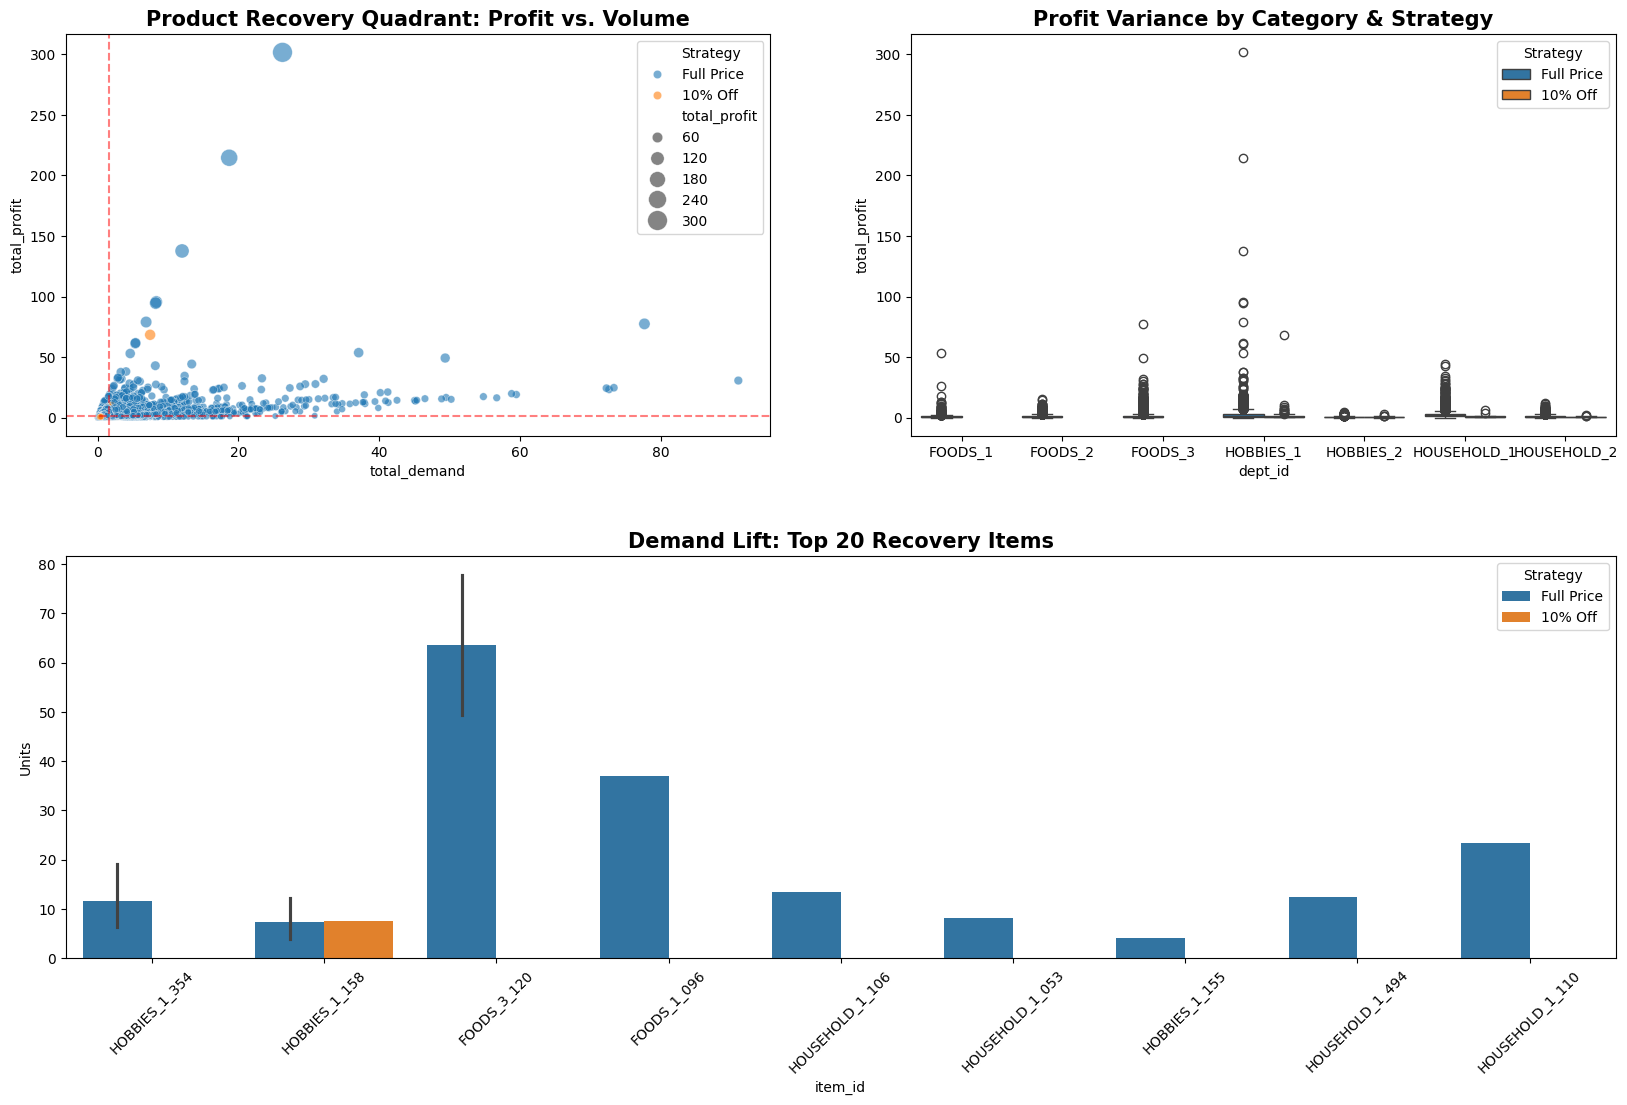

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_massy_professional_insights(df, simulation_matrix):
    """
    df: optimized_df (The chosen plan)
    simulation_matrix: full_sim_df (To compare against other choices)
    """
    # 1. CLEANING & RENAMING
    # Mapping d_0 to 'Full Price', etc.
    label_map = {'d_0': 'Full Price', 'd_10': '10% Off', 'd_20': '20% Off'}
    df['Strategy'] = df['scenario_id'].map(label_map)

    # 2. CALCULATING RECOVERY EFFICIENCY
    # Recovery Efficiency = (Profit with Discount / Profit at Full Price)
    # This shows if the discount was actually worth the margin loss
    df['Efficiency'] = df['total_profit'] / df['markdown_cost'].replace(0, 1)

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3)

    # --- GRAPH 1: QUADRANT ANALYSIS (The "Where to Focus") ---
    # High Profit vs High Demand
    ax1 = fig.add_subplot(gs[0, 0])
    sns.scatterplot(data=df, x='total_demand', y='total_profit', hue='Strategy',
                    size='total_profit', sizes=(20, 200), alpha=0.6, ax=ax1)
    ax1.set_title('Product Recovery Quadrant: Profit vs. Volume', fontsize=15, fontweight='bold')
    ax1.axhline(df['total_profit'].mean(), color='red', linestyle='--', alpha=0.5)
    ax1.axvline(df['total_demand'].mean(), color='red', linestyle='--', alpha=0.5)

    # --- GRAPH 2: PRICE ELASTICITY BY DEPARTMENT ---
    # This shows if Food or Hobbies actually reacts to the "Markdown"
    ax2 = fig.add_subplot(gs[0, 1])
    # Assuming 'dept_id' exists, otherwise use 'store_id'
    group_col = 'dept_id' if 'dept_id' in df.columns else 'store_id'
    sns.boxplot(data=df, x=group_col, y='total_profit', hue='Strategy', ax=ax2)
    ax2.set_title('Profit Variance by Category & Strategy', fontsize=15, fontweight='bold')

    # --- GRAPH 3: INVENTORY TURNOVER (Demand Lift) ---
    ax3 = fig.add_subplot(gs[1, :])
    # Compare Demand at Full Price vs Chosen Strategy for Top 20 Items
    top_items = df.nlargest(20, 'total_profit')
    top_items_melt = top_items.melt(id_vars=['item_id', 'Strategy'], value_vars=['total_demand'],
                                   var_name='Metric', value_name='Units')

    sns.barplot(data=top_items_melt, x='item_id', y='Units', hue='Strategy', ax=ax3)
    ax3.set_title('Demand Lift: Top 20 Recovery Items', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45)

    plt.show()

visualize_massy_professional_insights(result_df, simulation_matrix_df)

In [ ]:
simulation_matrix_df

,item_id,store_id,dept_id,total_demand,total_profit,markdown_cost,scenario_id
0,FOODS_1_001,CA_1,FOODS_1,1.000339,0.448152,0.000000,d_0
1,FOODS_1_002,CA_1,FOODS_1,0.660850,1.252971,0.000000,d_0
2,FOODS_1_003,CA_1,FOODS_1,0.976144,0.630589,0.000000,d_0
3,FOODS_1_004,CA_1,FOODS_1,9.693182,3.799727,0.000000,d_0
4,FOODS_1_005,CA_1,FOODS_1,1.570308,1.111778,0.000000,d_0
...,...,...,...,...,...,...,...
3044,HOUSEHOLD_2_512,WI_3,HOUSEHOLD_2,0.478331,0.284846,0.379795,d_20
3045,HOUSEHOLD_2_513,WI_3,HOUSEHOLD_2,0.688954,0.287294,0.383059,d_20
3046,HOUSEHOLD_2_514,WI_3,HOUSEHOLD_2,0.214812,0.629613,0.839484,d_20
3047,HOUSEHOLD_2_515,WI_3,HOUSEHOLD_2,0.410091,0.121182,0.161576,d_20


✅ Optimization Complete: Spent $10,000.00 of $10,000.00


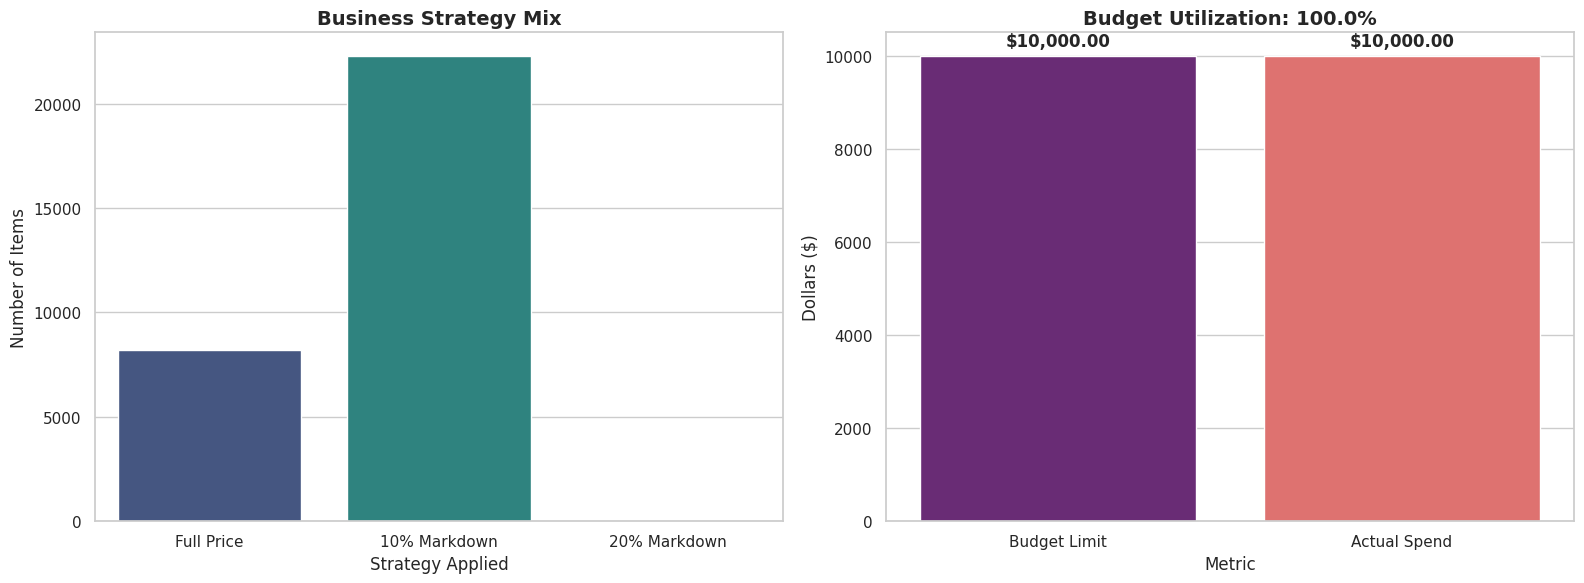

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_final_strict_heuristic(df_input, budget_limit):
    df = df_input.copy()

    # 1. Sort by Priority (Value for money)
    df['priority_score'] = df['total_demand'] / (df['markdown_cost'] + 0.01)

    # 2. Separate Full Price (Base) and Markdowns (Options)
    # We use 'Base' as the default starting point for everyone
    base_df = df[df['scenario_id'] == 'd_0'].set_index(['item_id', 'store_id'])
    markdown_options = df[df['scenario_id'] != 'd_0'].sort_values('priority_score', ascending=False)

    # 3. Greedy Selection
    selected_markdowns = []
    spent = 0
    covered_items = set()

    for idx, row in markdown_options.iterrows():
        key = (row['item_id'], row['store_id'])

        # Check: Enough Budget? AND Not already discounted?
        if key not in covered_items and (spent + row['markdown_cost'] <= budget_limit):
            selected_markdowns.append(row)
            spent += row['markdown_cost']
            covered_items.add(key)

        if spent >= budget_limit:
            break

    # 4. Create the Final Result
    # Start with the selected markdowns
    final_markdowns = pd.DataFrame(selected_markdowns)

    # Get the "Leftovers" (Items that didn't get a discount)
    # We take them from the base_df using the keys we DID NOT cover
    remaining_keys = base_df.index.difference(pd.MultiIndex.from_tuples(list(covered_items)))
    final_base = base_df.loc[remaining_keys].reset_index()

    # Combine
    result_df = pd.concat([final_markdowns, final_base], ignore_index=True)

    # 5. Map Labels for the Visuals
    label_map = {'d_0': 'Full Price', 'd_10': '10% Markdown', 'd_20': '20% Markdown'}
    result_df['strategy_label'] = result_df['scenario_id'].map(label_map)

    print(f"✅ Optimization Complete: Spent ${spent:,.2f} of ${budget_limit:,.2f}")
    return result_df

def visualize_heuristic_results(result_df, budget):
    # 1. PRE-CHECK: Ensure the required label column exists
    if 'strategy_label' not in result_df.columns:
        label_map = {'d_0': 'Full Price', 'd_10': '10% Markdown', 'd_20': '20% Markdown'}
        result_df['strategy_label'] = result_df['scenario_id'].map(label_map)

    # 2. SET THE THEME
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- GRAPH 1: STRATEGY MIX (The "What") ---
    # We use a defined order to ensure "Full Price" is always the first bar
    strategy_order = ['Full Price', '10% Markdown', '20% Markdown']
    sns.countplot(
        data=result_df,
        x='strategy_label',
        palette='viridis',
        order=strategy_order,
        ax=ax1
    )
    ax1.set_title('Business Strategy Mix', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Number of Items')
    ax1.set_xlabel('Strategy Applied')

    # --- GRAPH 2: BUDGET UTILIZATION (The "How Much") ---
    # We calculate the actual spend by filtering out the 'Full Price' (d_0) items
    actual_spend = result_df[result_df['scenario_id'] != 'd_0']['markdown_cost'].sum()

    usage_data = pd.DataFrame({
        'Metric': ['Budget Limit', 'Actual Spend'],
        'Amount': [budget, actual_spend]
    })

    sns.barplot(data=usage_data, x='Metric', y='Amount', palette='magma', ax=ax2)

    # Add a percentage indicator to the title
    utilization_pct = (actual_spend / budget) * 100
    ax2.set_title(f'Budget Utilization: {utilization_pct:.1f}%', fontweight='bold', fontsize=14)
    ax2.set_ylabel('Dollars ($)')

    # Add data labels on top of the bars for clarity
    for i, v in enumerate(usage_data['Amount']):
        ax2.text(i, v + (budget * 0.02), f"${v:,.2f}", ha='center', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

# --- RUN EVERYTHING ---
budget_val = 10000
result_df = run_final_strict_heuristic(simulation_matrix_df, budget_val)
visualize_heuristic_results(result_df, budget_val)